<a href="https://colab.research.google.com/github/ms-solly/idbi-hackathon-2026/blob/main/notebooks/04_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Model

## Objective

This notebook builds an XGBoost classifier for predicting loan default using the preprocessed **Give Me Some Credit** dataset.
 The model will be trained, evaluated, and compared with the Logistic Regression baseline.

 Objectives:
- Load the preprocessed dataset
- Train an XGBoost classifier
- Evaluate model performance
- Visualize the Confusion Matrix and ROC Curve
- Compare results with the Logistic Regression baseline

In [5]:
!git clone https://github.com/ms-solly/idbi-hackathon-2026.git

Cloning into 'idbi-hackathon-2026'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 40 (delta 9), reused 24 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 14.64 MiB | 14.86 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [6]:
%cd idbi-hackathon-2026

/content/idbi-hackathon-2026


In [7]:
import os
print(os.getcwd())

/content/idbi-hackathon-2026


## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

Load the processed data

In [9]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")

y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (223958, 10)
Testing Features: (30000, 10)
Training Labels: (223958,)
Testing Labels: (30000,)


Train the XGBoost Model

In [10]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


Make Predictions

In [11]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

Model Evaluation

In [12]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9062666666666667
Precision: 0.3471011746873816
Recall   : 0.456857855361596
F1 Score : 0.3944875107665805
ROC AUC  : 0.8451141747346227


Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.35      0.46      0.39      2005

    accuracy                           0.91     30000
   macro avg       0.65      0.70      0.67     30000
weighted avg       0.92      0.91      0.91     30000



Confusion Matrix

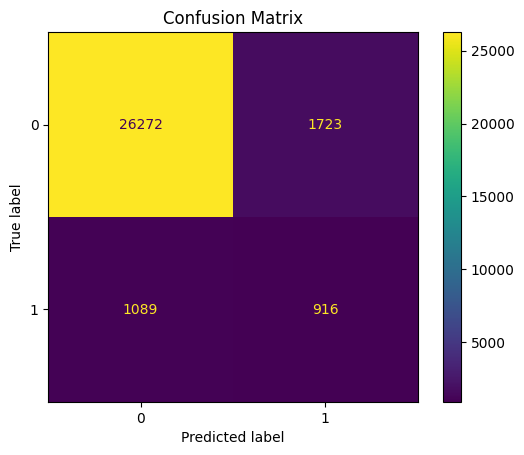

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

ROC Curve

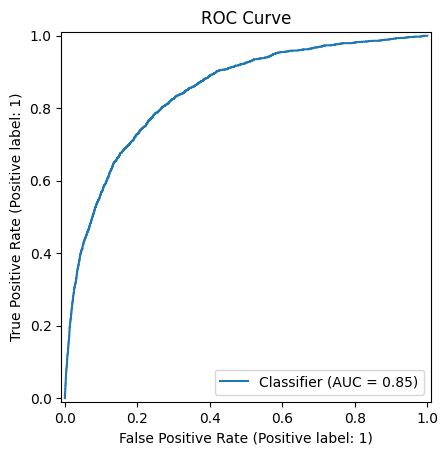

In [16]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")

plt.show()

## Conclusion

The XGBoost model was successfully trained and evaluated on the preprocessed loan default dataset.

Performance was measured using Accuracy, Precision, Recall, F1-score, ROC-AUC, the Classification Report, Confusion Matrix, and ROC Curve.

The evaluation metrics from this notebook can be compared with the Logistic Regression baseline to determine whether XGBoost provides improved predictive performance for loan default prediction.